# Predicting Energy Demand: A Regression Model
### Quick Start Orange County: AI Design Contest — Week 2

---

Your AI consulting firm has completed its data drawings of hospital energy data. You know what the Modesto
healthcare facility looks like — its shape, its gaps, its daily rhythms, and its relationship
with temperature.

Now you will use that knowledge to build something: a **regression model** that predicts
energy demand based on conditions your smart city can monitor in real time.

**Why regression?** Because energy demand is a continuous number — not a category,
not a yes/no decision. Regression is the right tool when the question is *how much?*

**What this model will do:** Given the hour of day, temperature, and other measurable
conditions, predict how much energy Modesto will draw from the grid. A smart city
system could use this prediction to pre-position power before demand spikes — reducing
the chance of an outage before it happens.

**By the end of this notebook your team will have:**
- Cleaned real data and justified every decision
- Engineered new features from raw data
- Trained and evaluated a linear regression model
- Interpreted what the model learned
- Stress-tested the model against emergency scenarios
- Written a reflection connecting model confidence to real stakes

**Keep your Data Profile from the Drawing with Data notebook on hand.
You will need it.**

---

## Setup

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

# Sanity check — tells you where Python is looking for your data file
print(f"Looking for data in: {os.getcwd()}")
print("Libraries loaded successfully")

Looking for data in: c:\Users\TAGZ1\Desktop\AI Smart Grid\week 2\Tasks 6–7 Notebook Files
Libraries loaded successfully


---
## Part 1: Load and Inspect

Every time you open a dataset you run the same three checks: shape, columns, head.
You did this in the Drawing with Data notebook. Do it here too — every time, no exceptions.
Datasets change. Assumptions break. Always verify.

In [3]:
# Load the dataset
df = pd.read_csv('modesto_energy_weather.csv', parse_dates=['timestamp'])

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Shape: 15,480 rows × 9 columns
Date range: 2016-03-26 12:00:00 → 2017-12-31 23:00:00

Columns: ['timestamp', 'Modesto_kWh', 'airTemperature', 'dewTemperature', 'windSpeed', 'hour', 'day_of_week', 'is_weekend', 'month']

First 5 rows:


,timestamp,Modesto_kWh,airTemperature,dewTemperature,windSpeed,hour,day_of_week,is_weekend,month
0,2016-03-26 12:00:00,731.775,11.5,10.5,8.8,12,5,1,3
1,2016-03-26 13:00:00,741.218,11.4,11.0,8.8,13,5,1,3
2,2016-03-26 14:00:00,739.735,12.4,10.9,9.3,14,5,1,3
3,2016-03-26 15:00:00,735.035,12.7,11.6,9.8,15,5,1,3
4,2016-03-26 16:00:00,746.526,13.4,11.9,10.3,16,5,1,3


In [4]:
# Basic statistics
df.describe().round(2)

,timestamp,Modesto_kWh,airTemperature,dewTemperature,windSpeed,hour,day_of_week,is_weekend,month
count,15480,13821.00,15479.00,15479.00,15480.00,15480.00,15480.00,15480.00,15480.00
mean,2017-02-12 05:10:27.441860,488.27,12.57,8.25,3.94,11.50,3.01,0.29,7.13
min,2016-03-26 12:00:00,93.48,-4.10,-7.30,0.00,0.00,0.00,0.00,1.00
25%,2016-09-03 18:45:00,329.82,8.35,4.70,2.60,6.00,1.00,0.00,5.00
50%,2017-02-12 06:30:00,426.73,12.60,8.70,3.60,12.00,3.00,0.00,7.00
75%,2017-07-23 12:15:00,568.18,16.70,12.00,5.10,18.00,5.00,1.00,10.00
max,2017-12-31 23:00:00,1267.85,33.90,20.70,18.50,23.00,6.00,1.00,12.00
std,NaN,204.03,6.03,4.92,2.08,6.92,2.00,0.45,3.20


In [5]:
# Exercise 1.1 — Read the numbers, answer in comments

# Q1: How many total rows does this dataset have? Is this larger or smaller
#     than any dataset you worked with in your Java AP CS course?
# A: 15,480, I'm not in APCSA, but have personally worked with bigger data sets (5.3 Million Columns, 40 rows lol).

# Q2: What is the mean energy consumption for Modesto in kWh?
#     What is the standard deviation? What does a high std tell you?
# A: The mean is 488.27, the std is 204.03 this tells me that the building has a high fluctuation in energy consumption.

# Q3: The temperature range goes from -4.1°C to 33.9°C.
#     Convert both to Fahrenheit (F = C × 9/5 + 32).
#     Does this feel like a Florida climate? What does that tell you about
#     where this data was collected?
# A: No, the max is 93.02 which is to low for florida and the min is 24.62, both of which are too low for florida, 
# this is likley in the mid US, maybe georgia as it still is too warm for the midwest.

print(f'Min: {-4.1 * 9 / 5 +32}')
print(f'Min: {33.9 * 9 / 5 +32}')

# Q4: Look at your Data Profile from the Drawing with Data notebook.
#     Does the Modesto range here match what you recorded there?
#     If not, why might they differ?
# A: Yes they match

Min: 24.62
Min: 93.02


---
## Part 2: Data Cleaning

In the Drawing with Data notebook you saw that Modesto has missing values.
Now you have to decide what to do about them — and justify your decision.

There is no universally correct answer. Different choices produce different models.
What matters is that you can defend your choice.

In [6]:
# Step 1: Quantify the missing data
print("Missing value counts:")
print("-" * 40)
for col in df.columns:
    n = df[col].isna().sum()
    pct = n / len(df) * 100
    if n > 0:
        print(f"{col:<25} {n:>5} missing  ({pct:.1f}%)")
    else:
        print(f"{col:<25} complete")

Missing value counts:
----------------------------------------
timestamp                 complete
Modesto_kWh                1659 missing  (10.7%)
airTemperature                1 missing  (0.0%)
dewTemperature                1 missing  (0.0%)
windSpeed                 complete
hour                      complete
day_of_week               complete
is_weekend                complete
month                     complete


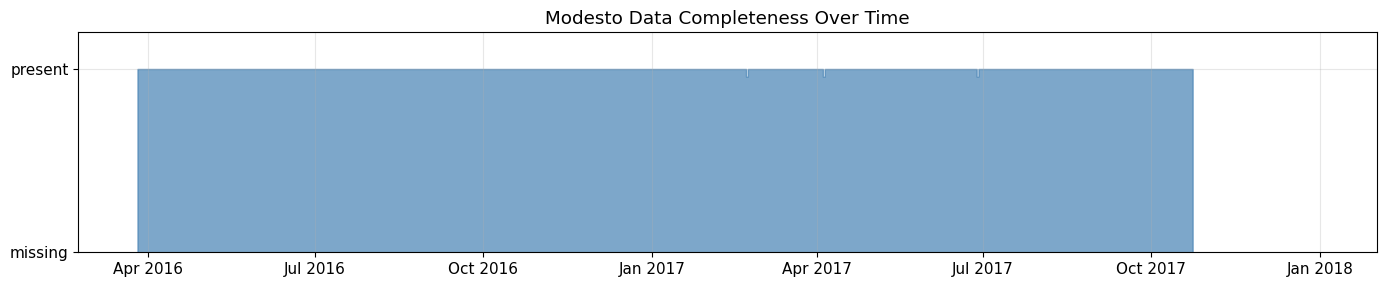

In [7]:
# Step 2: Visualize when the gaps occur
# Are missing values random or clustered in time?

fig, ax = plt.subplots(figsize=(14, 3))
daily_complete = df.set_index('timestamp')['Modesto_kWh'].notna().resample('D').mean()
ax.fill_between(daily_complete.index, daily_complete.values,
                color='steelblue', alpha=0.7, step='mid')
ax.set_ylim(0, 1.2)
ax.set_yticks([0, 1])
ax.set_yticklabels(['missing', 'present'])
ax.set_title('Modesto Data Completeness Over Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

In [8]:
# Step 3: Investigate suspicious values
# Are there any extreme outliers that might be data errors?

print("Modesto_kWh distribution at the extremes:")
print(f"  Minimum:      {df['Modesto_kWh'].min():.1f} kWh")
print(f"  1st pctile:   {df['Modesto_kWh'].quantile(0.01):.1f} kWh")
print(f"  99th pctile:  {df['Modesto_kWh'].quantile(0.99):.1f} kWh")
print(f"  Maximum:      {df['Modesto_kWh'].max():.1f} kWh")
print(f"\nRows where Modesto_kWh < 100 kWh:")
print(df[df['Modesto_kWh'] < 100][['timestamp','Modesto_kWh','hour']].head(10))

Modesto_kWh distribution at the extremes:
  Minimum:      93.5 kWh
  1st pctile:   264.4 kWh
  99th pctile:  1102.3 kWh
  Maximum:      1267.8 kWh

Rows where Modesto_kWh < 100 kWh:
               timestamp  Modesto_kWh  hour
8743 2017-03-26 02:00:00       93.482     2


In [9]:
# Exercise 2.1 — YOUR CLEANING DECISIONS
# You make three decisions here. For each one, write your reasoning
# as a comment BEFORE writing the code. A judge may ask you to defend these.

# DECISION 1: How will you handle missing Modesto_kWh values?
# Options: drop the rows | fill with mean | fill with median | 
#          fill with the previous valid value (forward fill)
# 
# Our reasoning: drop the rows, filling with the mean or median could dilute the data faltening out potentially extreme value, 
# as the missing values are spread out, I find it best to drop them
# 

# YOUR CODE HERE — implement Decision 1
df_clean = df.copy()
df_clean = df_clean.dropna(subset=['Modesto_kWh'])


# DECISION 2: The minimum Modesto value is very low (< 100 kWh).
# Should you keep these rows or treat them as suspect data?
#
# Our reasoning: I will treat them as suspect data, there is only a single value under 100kwh, and the 1st percentile is over double this, so it is likley a data collection error of some form.
#

# YOUR CODE HERE — implement Decision 2 (or explicitly decide to keep all rows)
df_clean = df_clean[df_clean['Modesto_kWh'] >= 100]

# DECISION 3: Are there any weather columns with missing values you need to handle?
# Check above and decide.
#
# Our reasoning: There is one column with no temperature data, due to the size of the data set and the fact that there is only one missing temperature I believe it will be safe to drop this column
#

# YOUR CODE HERE — implement Decision 3
df_clean = df_clean.dropna(subset=['airTemperature', 'dewTemperature'])

print(f"Rows before cleaning: {len(df):,}")
print(f"Rows after cleaning:  {len(df_clean):,}")
print(f"Rows removed:         {len(df) - len(df_clean):,}")

Rows before cleaning: 15,480
Rows after cleaning:  13,819
Rows removed:         1,661


---
## Part 3: Feature Engineering

Raw data columns are rarely the best features for a model. **Feature engineering**
means creating new columns that capture relationships you already understand from
drawing the data.

Think of it as giving the model better brushes. A model can only find patterns
in the features you hand it. If an important pattern lives in a combination
of two columns — temperature AND time of day together — you have to create
that combined feature yourself.

Below are four features to engineer. For each one:
1. Read the explanation of *why* it might be useful
2. Fill in the formula
3. Write one sentence justifying why you included it

In [10]:
# Feature 1: is_business_hours
# Healthcare facilities run 24/7 but staffing and activity differ dramatically
# between business hours (8am-6pm) and overnight.
# This binary flag captures that shift pattern.

# YOUR CODE: Create a column that is 1 if hour is between 8 and 18, else 0
# Hint: use a boolean condition like (df_clean['hour'] >= 8) & (df_clean['hour'] <= 18)
# then convert True/False to 1/0 using .astype(int)
# Example pattern: df_clean['col'] = (condition).astype(int)

df_clean['is_business_hours'] = ((df_clean['hour'] >= 8) & (df_clean['hour']  <= 18)).astype(int)
# Justification (one sentence):
#Adds a row to df_clean with either a 0 or 1 to represent if it is in buisness hours.

# Verify it worked — should show two values: 0 and 1
print('is_business_hours value counts:')
print(df_clean['is_business_hours'].value_counts())


is_business_hours value counts:
is_business_hours
0    7486
1    6333
Name: count, dtype: int64


In [11]:
# Feature 2: temp_squared
# The relationship between temperature and energy is not perfectly linear.
# At moderate temperatures, HVAC runs lightly. At extremes (very hot OR very cold)
# it runs hard. Squaring the temperature captures this nonlinear behavior.
# This is called a polynomial feature.

# YOUR CODE: Create a column that is airTemperature squared
# Hint: use ** 2 to square a value in Python
# Example pattern: df_clean['col'] = df_clean['some_column'] ** 2

df_clean['temp_squared'] = df_clean['airTemperature'] ** 2

# Justification (one sentence):
#Simply squares the air temp and puts it in a new column

print(f"temp_squared range: {df_clean['temp_squared'].min():.1f} to {df_clean['temp_squared'].max():.1f}")


temp_squared range: 0.0 to 1149.2


In [12]:
# Feature 3: temp_x_hour (interaction term)
# The effect of temperature on energy demand is different at different times of day.
# A hot afternoon drives air conditioning harder than a warm midnight.
# An interaction term captures this combined effect.
# In your data drawing, did you see temperature matter more at certain hours?

# YOUR CODE: Create a column that is airTemperature multiplied by hour
# Hint: you can multiply two DataFrame columns using *

df_clean['temp_x_hour'] = df_clean['airTemperature'] * df_clean['hour']

# Justification (one sentence):
#This multiplies the air temp by the hour

print(f"temp_x_hour range: {df_clean['temp_x_hour'].min():.1f} to {df_clean['temp_x_hour'].max():.1f}")


temp_x_hour range: -59.8 to 572.4


In [13]:
# Feature 4: rolling_mean_3h
# Energy demand has momentum — if the last 3 hours have been high,
# the next hour is likely to also be high. This rolling average
# captures that temporal momentum.
# This is a common feature in time series forecasting.

# Given — rolling mean requires careful handling so we build it for you
df_clean = df_clean.sort_values('timestamp').reset_index(drop=True)
df_clean['rolling_mean_3h'] = (
    df_clean['Modesto_kWh']
    .rolling(window=3, min_periods=1)
    .mean()
    .shift(1)   # shift by 1 so we don't leak future data into the feature
)

# Justification (one sentence — why is the shift(1) important?):
# It makes sure the average is using past data and not the data its currently trying to predict

print(f"rolling_mean_3h sample:")
print(df_clean[['timestamp','Modesto_kWh','rolling_mean_3h']].head(8))

rolling_mean_3h sample:
            timestamp  Modesto_kWh  rolling_mean_3h
0 2016-03-26 12:00:00      731.775              NaN
1 2016-03-26 13:00:00      741.218       731.775000
2 2016-03-26 14:00:00      739.735       736.496500
3 2016-03-26 15:00:00      735.035       737.576000
4 2016-03-26 16:00:00      746.526       738.662667
5 2016-03-26 17:00:00      741.881       740.432000
6 2016-03-26 18:00:00      742.129       741.147333
7 2016-03-26 19:00:00      738.699       743.512000


In [14]:
# Exercise 3.1 — Design your own feature
# Based on what you saw in the Drawing with Data notebook,
# create ONE additional feature that you think will help the model.
#
# Ideas (pick one or invent your own):
#   - is_winter: 1 if month is Nov/Dec/Jan/Feb, else 0
#   - temp_dew_diff: difference between air temp and dew point (humidity proxy)
#   - is_monday: 1 if day_of_week == 0 (Mondays often have unusual patterns)
#   - hour_squared: captures nonlinear time-of-day effects
#
# Example patterns:
#   df_clean['col'] = df_clean['col_a'] - df_clean['col_b']   # difference
#   df_clean['col'] = (df_clean['col_a'] == value).astype(int) # binary flag
#   df_clean['col'] = df_clean['col_a'] ** 2                   # squared

# Feature name: (rename 'my_feature' to something descriptive)
# YOUR CODE:
df_clean['is_winter'] = ((df_clean['month'] >= 11) | (df_clean['month'] <= 2)).astype(int)


# Why did you create this feature? What pattern from your data drawings
# suggested it would be useful?
# JUSTIFICATION: There apears to be a significant change in energy consumption over the seasons, so this will let the model know if it is winter or not.
#

print(f"is_winter stats:\n{df_clean['is_winter'].describe().round(2)}")


is_winter stats:
count    13819.00
mean         0.21
std          0.41
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          1.00
Name: is_winter, dtype: float64


In [15]:
# Final check — what features do we have available?
all_features = ['hour', 'day_of_week', 'is_weekend', 'month',
                'airTemperature', 'dewTemperature', 'windSpeed',
                'is_business_hours', 'temp_squared', 'temp_x_hour',
                'rolling_mean_3h', 'is_winter']

# Drop any remaining NaNs introduced by rolling mean
df_model = df_clean[all_features + ['Modesto_kWh']].dropna()
print(f"Rows available for modeling: {len(df_model):,}")
print(f"Features available: {len(all_features)}")
print(f"\nFeature list: {all_features}")

Rows available for modeling: 13,818
Features available: 12

Feature list: ['hour', 'day_of_week', 'is_weekend', 'month', 'airTemperature', 'dewTemperature', 'windSpeed', 'is_business_hours', 'temp_squared', 'temp_x_hour', 'rolling_mean_3h', 'is_winter']


---
## Part 4: Feature Selection and Model Training

Having features available does not mean you should use all of them.
Choosing which features to include is one of the most important decisions
a data scientist makes — and one of the hardest to get right.

**Recall from the Drawing with Data notebook:** you computed correlations
between features and Modesto's energy demand. Use that knowledge now.

**Your team must choose at least 5 features and no more than 10.**
Every feature you include must be justified.

In [16]:
# Correlation reminder — which features relate most strongly to Modesto_kWh?
corr = df_model.corr()['Modesto_kWh'].drop('Modesto_kWh').sort_values(key=abs, ascending=False)
print("Feature correlations with Modesto_kWh (strongest first):")
print("-" * 45)
for feat, val in corr.items():
    bar = '█' * int(abs(val) * 20)
    direction = '+' if val > 0 else '-'
    print(f"{feat:<22} {val:>7.3f}  {direction}{bar}")

Feature correlations with Modesto_kWh (strongest first):
---------------------------------------------
rolling_mean_3h          0.976  +███████████████████
is_winter               -0.373  -███████
airTemperature           0.276  +█████
temp_squared             0.260  +█████
temp_x_hour              0.245  +████
month                   -0.191  -███
is_business_hours        0.181  +███
dewTemperature           0.157  +███
hour                     0.118  +██
is_weekend              -0.109  -██
day_of_week             -0.094  -█
windSpeed                0.042  +


In [17]:
# Exercise 4.1 — YOUR FEATURE SELECTION
# Choose your features. Write your reasoning for EACH one.
# Use the correlation table above AND your Data Profile.
# Remove features from the list below or add your own.
# You must include at least 5 features and no more than 10.

# FEATURES WE ARE INCLUDING AND WHY:
# 1. airTemperature  — because: Strong correlation and an important factor 
# 2. hour            — because: good correlation but very important 
# 3. temp x hour     — because: procides a good index of how the two correlate with eachother 
# 4. month           — because: Provides a larger scale view of time 
# 5. temp_squared    — because: Exponetial view of temperature.
# 6. day_of_week     - because: Gives a representation of time on week scale
# 7. Rolling mean    - because: great correlation to boost prediction scores
# 8. is_buisness_hours - because: Gives insight into the differneces between buisness hours and not 
# (add more if needed)

# FEATURES WE ARE EXCLUDING AND WHY:
# 1. Windspeed       — because: Almost 0 correlation 
# 2. Dew Temp        — because: Just not needed with the inclusion of air temperature, kinda irrelevant with low poer consumption.
# 3. is_winter       - because: month takes care of this
# 4. is_weekend      - bacause: day of week takes care of this

# Edit this list — add or remove feature names as strings
# All names must exactly match column names in df_model
selected_features = [
    'airTemperature',
    'hour',
    'month',
    'is_business_hours',
    'temp_squared',
    'temp_x_hour',
    'rolling_mean_3h',
    'day_of_week',
]


X = df_model[selected_features]
y = df_model['Modesto_kWh']

print(f"Selected {len(selected_features)} features: {selected_features}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


Selected 8 features: ['airTemperature', 'hour', 'month', 'is_business_hours', 'temp_squared', 'temp_x_hour', 'rolling_mean_3h', 'day_of_week']
X shape: (13818, 8)
y shape: (13818,)


In [18]:
# Train / test split
# 80% of data for training, 20% held out for honest evaluation
# random_state=42 ensures everyone gets the same split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows:  {len(X_train):,}")
print(f"Test rows:      {len(X_test):,}")
print(f"\nThe model will NEVER see the {len(X_test):,} test rows during training.")
print(f"Those rows are our honest evaluation set.")

Training rows:  11,054
Test rows:      2,764

The model will NEVER see the 2,764 test rows during training.
Those rows are our honest evaluation set.


In [19]:
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")
print(f"\nWhat the model learned — coefficients:")
print("-" * 45)
for feature, coef in zip(selected_features, model.coef_):
    direction = 'increases' if coef > 0 else 'decreases'
    print(f"{feature:<22} {coef:>8.2f}  → 1 unit increase {direction} demand by {abs(coef):.2f} kWh")
print(f"\nIntercept: {model.intercept_:.2f} kWh (baseline demand with all features at zero)")

Model trained successfully.

What the model learned — coefficients:
---------------------------------------------
airTemperature            -0.23  → 1 unit increase decreases demand by 0.23 kWh
hour                      -0.65  → 1 unit increase decreases demand by 0.65 kWh
month                     -0.32  → 1 unit increase decreases demand by 0.32 kWh
is_business_hours         40.75  → 1 unit increase increases demand by 40.75 kWh
temp_squared               0.05  → 1 unit increase increases demand by 0.05 kWh
temp_x_hour               -0.07  → 1 unit increase decreases demand by 0.07 kWh
rolling_mean_3h            0.98  → 1 unit increase increases demand by 0.98 kWh
day_of_week               -0.50  → 1 unit increase decreases demand by 0.50 kWh

Intercept: 6.00 kWh (baseline demand with all features at zero)


In [ ]:
# Exercise 4.2 — Interpreting the coefficients

# Q1: Which feature has the largest positive coefficient?
#     What does that mean physically for the Modesto facility?
# A: is_buisness_hours has the largest positive coefficent, this means that the Modesto facility takes significantly more power during buisness hours.

# Q2: Which feature has the largest negative coefficient?
#     What does that mean physically?
# A: The hour has the largest negative coefficent, this means that the larger the hour the less power needed.

# Q3: Does the direction (positive/negative) of each coefficient
#     match your intuition from the Drawing with Data notebook? Mostly exept for air tempt
#     Was there anything surprising? 
# A: I thought that air temp would increase power need as drawing with data showed, but its the oppisite, instead it decreases power demand.

# Q4: The intercept is the predicted demand when ALL features equal zero.
#     Is that a realistic scenario? (Hour = 0, temp = 0°C, etc.)
#     What does this tell you about the limits of linear regression?
# A: It creates a single linear line, it completly ignore variable correlation.

---
## Part 5: Evaluation and Visualization

A model is only as trustworthy as its evaluation. We use three metrics:

- **MAE (Mean Absolute Error)** — on average, how many kWh off is each prediction?
- **RMSE (Root Mean Square Error)** — like MAE but penalizes large errors more heavily
- **R² (R-squared)** — what fraction of demand variation does the model explain?
  - R² = 1.0: perfect predictions
  - R² = 0.0: no better than predicting the mean every time
  - R² < 0.0: worse than predicting the mean

All three are evaluated on the **test set only** — data the model never saw.

In [21]:
# Generate predictions on test set
y_pred = model.predict(X_test)

# Calculate metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("Model Performance on Test Set")
print("=" * 40)
print(f"MAE:   {mae:.1f} kWh   (average prediction error)")
print(f"RMSE:  {rmse:.1f} kWh  (large-error-penalized average)")
print(f"R²:    {r2:.3f}        (fraction of variance explained)")
print()
print(f"Context: Modesto mean demand is ~{y.mean():.0f} kWh")
print(f"         MAE as % of mean: {mae/y.mean()*100:.1f}%")

Model Performance on Test Set
MAE:   25.8 kWh   (average prediction error)
RMSE:  41.2 kWh  (large-error-penalized average)
R²:    0.958        (fraction of variance explained)

Context: Modesto mean demand is ~488 kWh
         MAE as % of mean: 5.3%


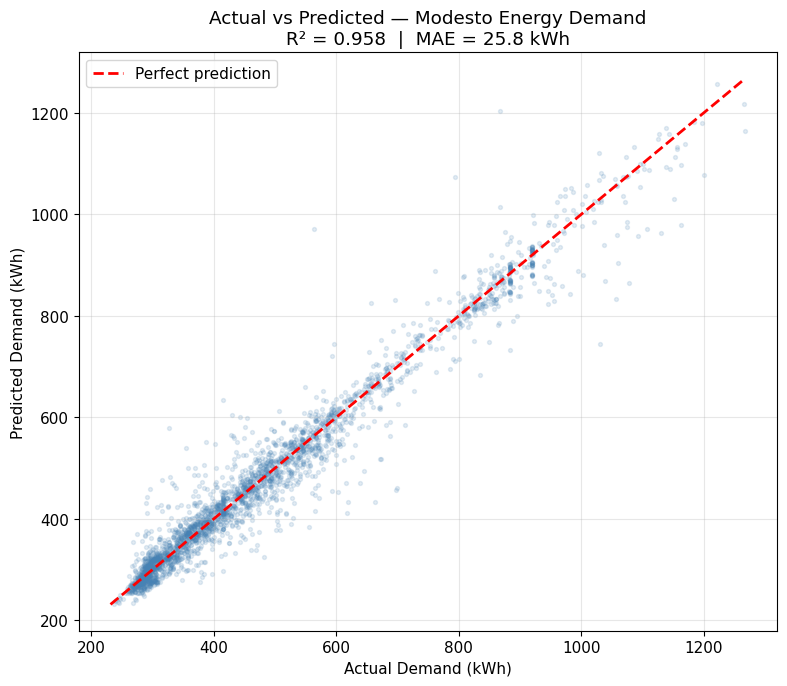

In [22]:
# Plot 1: Actual vs Predicted
# Points on the diagonal line = perfect prediction
# Points above the line = model under-predicted
# Points below the line = model over-predicted

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(y_test, y_pred, alpha=0.15, s=8, color='steelblue')

# Perfect prediction line
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')

ax.set_xlabel('Actual Demand (kWh)')
ax.set_ylabel('Predicted Demand (kWh)')
ax.set_title(f'Actual vs Predicted — Modesto Energy Demand\nR² = {r2:.3f}  |  MAE = {mae:.1f} kWh')
ax.legend()
plt.tight_layout()
plt.show()

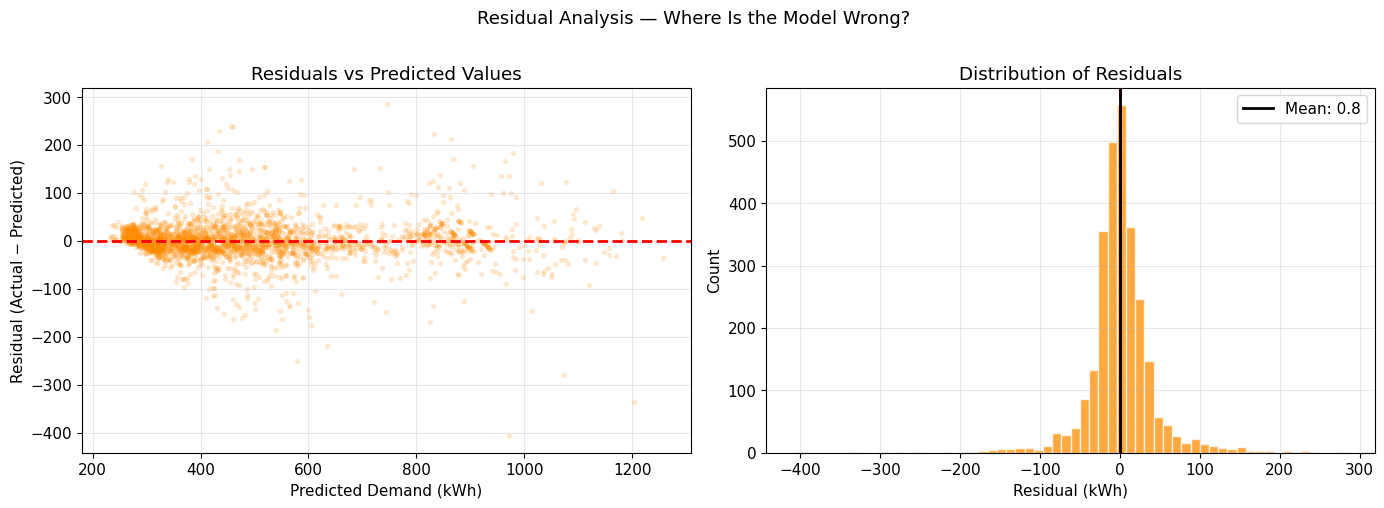

In [23]:
# Plot 2: Residuals
# A residual is the error for each prediction: actual - predicted
# Positive residual = model under-predicted (actual was higher)
# Negative residual = model over-predicted (actual was lower)
#
# What we WANT to see: residuals scattered randomly around zero
# What we DON'T want: a pattern in the residuals (means the model missed something)

residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs predicted values
axes[0].scatter(y_pred, residuals, alpha=0.15, s=8, color='darkorange')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Demand (kWh)')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residuals vs Predicted Values')

# Residuals distribution
axes[1].hist(residuals, bins=60, color='darkorange', alpha=0.75, edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].axvline(x=residuals.mean(), color='black', linestyle='-',
                linewidth=2, label=f'Mean: {residuals.mean():.1f}')
axes[1].set_xlabel('Residual (kWh)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals')
axes[1].legend()

plt.suptitle('Residual Analysis — Where Is the Model Wrong?', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [24]:
# Exercise 5.1 — Reading the evaluation

# Q1: Your MAE is printed above in kWh. Is that a large or small error
#     relative to Modesto's mean demand? Would you trust this model
#     to make real-time grid decisions?
# A: It is about 5.3% of the mean demand, while not to bad it is still possible to do better and I would not trust it.

# Q2: Look at the Actual vs Predicted scatter plot.
#     Are there regions where the model consistently under-predicts?
#     (points above the diagonal) Where does this happen?
# A: This happens consistently, but is concentrated at lower actual demand ( < 400kWh)

# Q3: Look at the residuals vs predicted values plot.
#     Is there a pattern, or are the residuals randomly scattered?
#     If there IS a pattern, what might that tell you about what
#     the model is missing?
# A: They are mostly random scattered randomly but do have some pattern specifically a sot of v shape of max/mins as the demand increases

# Q4: The residuals histogram — is it roughly symmetric around zero?
#     A symmetric distribution means the model is not systematically
#     biased in one direction. What do you observe?
# A: It is not biased in one direction.

# Q5: If you were presenting this model to the city council and they asked
#     'how accurate is your prediction?' — what would you say?
#     Use specific numbers from your evaluation.
# A: The model is accurate for the average, but not the true usage. It has an average prediction error of 25.8kWh making up about 5.3% of the mean power consumption.

---
## Part 6: Stress-Testing with Emergency Scenarios

A regression model trained on normal conditions will be used during emergencies.
Before trusting it, you need to understand how it behaves when conditions
fall outside the patterns it learned.

This is called **scenario analysis** — changing one or more inputs deliberately
and observing how the prediction changes.

**Important:** In a real emergency, we do not know the true demand.
We are testing whether the model's response makes directional sense —
does it predict more demand when we increase a stress factor? Less when we decrease?
A model that responds in the wrong direction is dangerous.

In [25]:
# Scenario 1: Heat Wave
# Extreme heat increases cooling load throughout the facility.
# We simulate this by adding 8°C to every test temperature.

heat_wave = X_test.copy()
heat_wave['airTemperature'] = heat_wave['airTemperature'] + 8

# Update engineered features that depend on temperature
if 'temp_squared' in selected_features:
    heat_wave['temp_squared'] = heat_wave['airTemperature'] ** 2
if 'temp_x_hour' in selected_features:
    heat_wave['temp_x_hour'] = heat_wave['airTemperature'] * heat_wave['hour']

heat_wave_pred = model.predict(heat_wave)

print("Scenario 1: Heat Wave (+8°C)")
print("-" * 40)
print(f"Original average demand:   {y_test.mean():.1f} kWh")
print(f"Heat wave average demand:  {heat_wave_pred.mean():.1f} kWh")
print(f"Change:                    {heat_wave_pred.mean() - y_test.mean():+.1f} kWh ({(heat_wave_pred.mean()/y_test.mean()-1)*100:+.1f}%)")

Scenario 1: Heat Wave (+8°C)
----------------------------------------
Original average demand:   490.1 kWh
Heat wave average demand:  494.6 kWh
Change:                    +4.5 kWh (+0.9%)


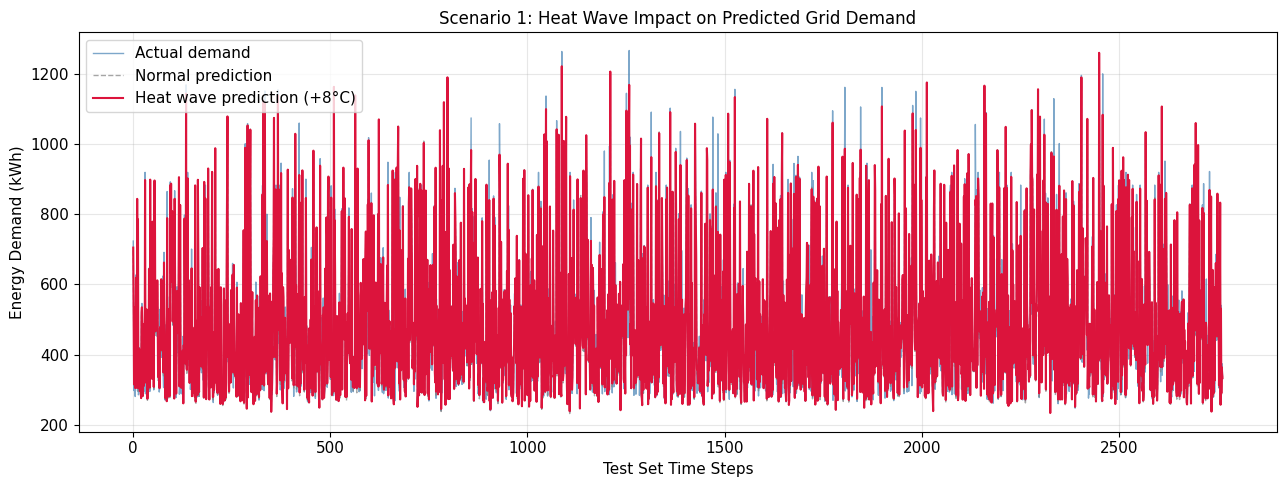

In [26]:
# Plot Scenario 1
fig, ax = plt.subplots(figsize=(13, 5))

x_axis = range(len(y_test))
ax.plot(x_axis, y_test.values, label='Actual demand', 
        color='steelblue', linewidth=1, alpha=0.7)
ax.plot(x_axis, y_pred, label='Normal prediction', 
        color='gray', linewidth=1, linestyle='--', alpha=0.7)
ax.plot(x_axis, heat_wave_pred, label='Heat wave prediction (+8°C)', 
        color='crimson', linewidth=1.5)

ax.set_title('Scenario 1: Heat Wave Impact on Predicted Grid Demand', fontsize=12)
ax.set_xlabel('Test Set Time Steps')
ax.set_ylabel('Energy Demand (kWh)')
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
# Scenario 2: Hospital Surge
# During a mass casualty event, hospital energy demand increases as
# emergency systems, operating rooms, and ICU equipment run at full capacity.
#
# STUDENT TASK:
# Choose a realistic surge multiplier between 1.10 and 1.30 (10% to 30% increase).
# Justify your choice — why that specific percentage?

# Our chosen multiplier and reasoning:
# Multiplier: 1.25
# Reasoning: During a mass casualty event, being the only hosbital in the city, this hosbital would take on all of the effected people, resulting in a surge multiplier on the higher end.

SURGE_MULTIPLIER = 1.25  # REPLACE 1.20 with your chosen multiplier (1.10 to 1.30)

# Note: rolling_mean_3h already reflects Modesto's baseline.
# We model the surge as increased temperature load (HVAC + equipment heat).
hospital_surge = X_test.copy()
hospital_surge['airTemperature'] = hospital_surge['airTemperature'] * SURGE_MULTIPLIER

if 'temp_squared' in selected_features:
    hospital_surge['temp_squared'] = hospital_surge['airTemperature'] ** 2
if 'temp_x_hour' in selected_features:
    hospital_surge['temp_x_hour'] = hospital_surge['airTemperature'] * hospital_surge['hour']

hospital_surge_pred = model.predict(hospital_surge)

print(f"Scenario 2: Hospital Surge (×{SURGE_MULTIPLIER})")
print("-" * 40)
print(f"Surge average demand:      {hospital_surge_pred.mean():.1f} kWh")
print(f"Change:                    {hospital_surge_pred.mean() - y_test.mean():+.1f} kWh ({(hospital_surge_pred.mean()/y_test.mean()-1)*100:+.1f}%)")

Scenario 2: Hospital Surge (×1.25)
----------------------------------------
Surge average demand:      491.5 kWh
Change:                    +1.5 kWh (+0.3%)


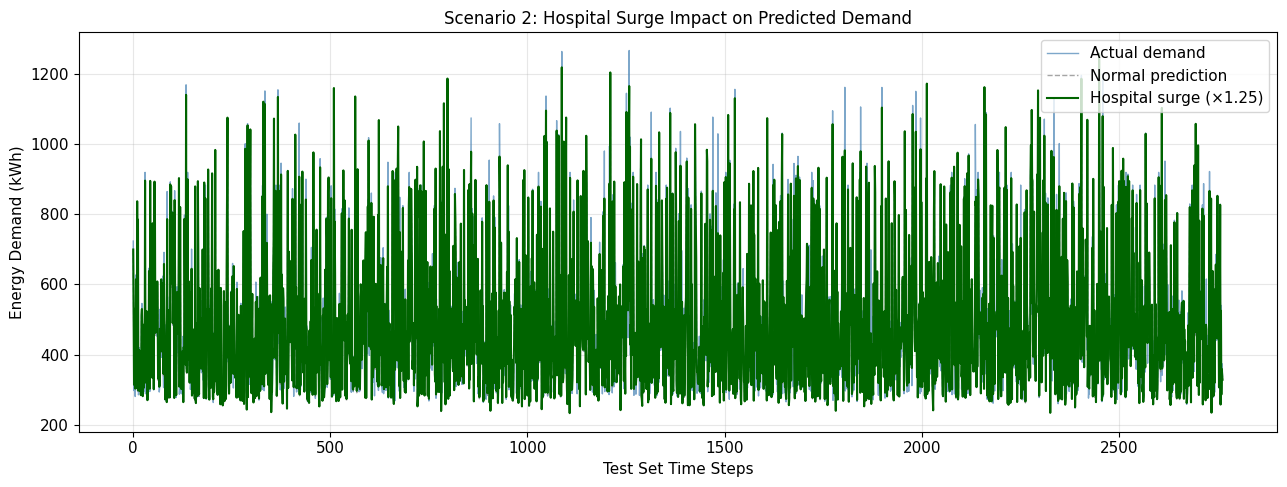

In [28]:
# Plot Scenario 2
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(x_axis, y_test.values, label='Actual demand',
        color='steelblue', linewidth=1, alpha=0.7)
ax.plot(x_axis, y_pred, label='Normal prediction',
        color='gray', linewidth=1, linestyle='--', alpha=0.7)
ax.plot(x_axis, hospital_surge_pred, label=f'Hospital surge (×{SURGE_MULTIPLIER})',
        color='darkgreen', linewidth=1.5)

ax.set_title(f'Scenario 2: Hospital Surge Impact on Predicted Demand', fontsize=12)
ax.set_xlabel('Test Set Time Steps')
ax.set_ylabel('Energy Demand (kWh)')
ax.legend()
plt.tight_layout()
plt.show()

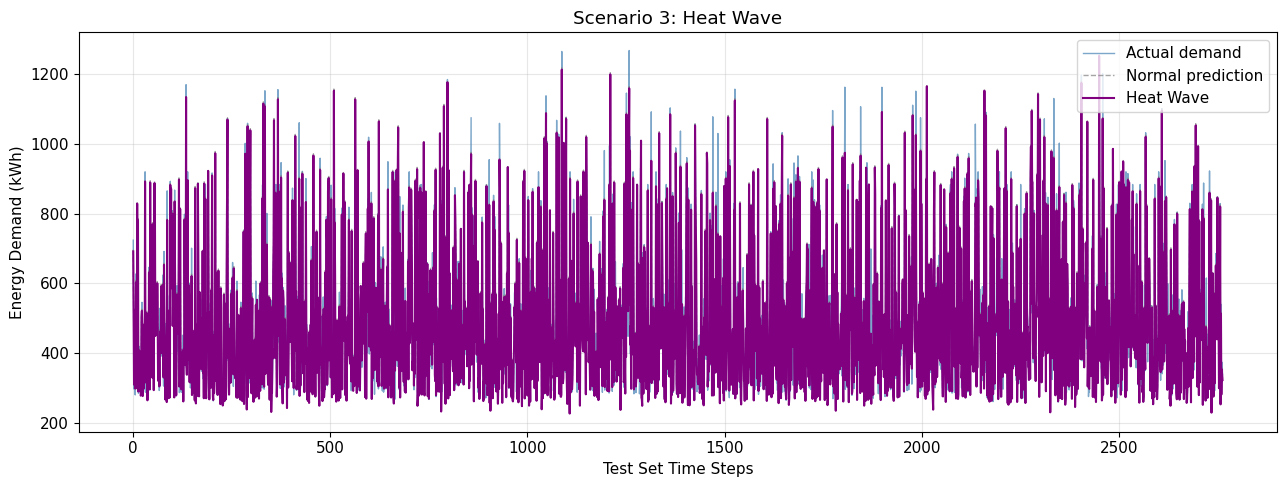

Average demand change: -5.6 kWh



In [29]:
# Scenario 3: YOUR TEAM'S EMERGENCY SCENARIO
#
# Design a realistic emergency scenario by modifying one or two features.
# Examples:
#   - Winter storm: drop temperature by 15°C, is_weekend = 0 (staff called in)
#   - Power grid brownout: model what reduced demand looks like
#   - Overnight emergency: filter to nighttime hours only, surge temperature
#
# REQUIREMENTS:
#   1. Name your scenario
#   2. Describe what real-world event it represents
#   3. Explain which features you modified and why
#   4. Plot actual vs your scenario prediction
#   5. Interpret the result — does the model respond sensibly?

# Scenario name: Summer heat wave
# Real-world event: July 2025 Heat Dome
# Features modified and why: 
# Temp + 15C, heat wave is hotter
# surge factor = 1.2, more people getting heat sick/ dehydrated

heat_wave = X_test.copy()

# YOUR MODIFICATIONS HERE
heat_wave['airTemperature'] = heat_wave['airTemperature'] + 15
heat_wave['airTemperature'] = heat_wave['airTemperature'] * 1.2 # SURGE is here

heat_wave_pred = model.predict(heat_wave)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(x_axis, y_test.values, label='Actual demand', 
        color='steelblue', linewidth=1, alpha=0.7)
ax.plot(x_axis, y_pred, label='Normal prediction',
        color='gray', linewidth=1, linestyle='--', alpha=0.7)
ax.plot(x_axis, heat_wave_pred, label='Heat Wave',
        color='purple', linewidth=1.5)

ax.set_title('Scenario 3: Heat Wave')
ax.set_xlabel('Test Set Time Steps')
ax.set_ylabel('Energy Demand (kWh)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Average demand change: {heat_wave_pred.mean() - y_test.mean():+.1f} kWh")
print()
# Interpretation — does the model respond in the direction you expected?
# YOUR ANSWER: No, the demand change decreased when it was instead expected to increase.

---
## Part 7: The Bridge to Classification

You now have a model that predicts energy demand. But prediction alone
is not enough for a smart city emergency response system.

**The harder question:** when predicted demand exceeds available supply,
*who* gets power and *who* waits?

That is a classification problem — and it is what you will build next week.
Before you get there, this reflection connects what you built here
to what comes next.

In [30]:
# Final Reflection — answer all five questions
# Write your team's answers as comments.
# These answers will inform your classification notebook design.

# Q1: Your model has an MAE of approximately 25.8 kWh.
#     During a heat wave scenario, predicted demand increased by -5.6 kWh.
#     Is the prediction error large or small relative to the scenario change? Very small, almost none at all
#     What does that tell you about how much to trust the model during emergencies? Can't really be trusted during an emergency as it dosen't acuratly predict the needed change.
# A: 

# Q2: Your model was trained on data from one building — Modesto.
#     The smart city has many different types of users.
#     List two reasons why this model might NOT generalize to a grocery store
#     or a school.
# A: 1. Differnt energy levels, the constant HVAC and equipment in a hosbital consumes significantly more energy than a school or grocery store does.
#    2. They have differnt usage patterns, nobody is in a school or grocery shopping at night while they are closed, but people are still having emergencys and going to the hospital

# Q3: The residuals plot showed where the model was most wrong.
#     If those errors happened during a real emergency, what would the
#     consequence be for the smart city? (Think about both over-prediction
#     and under-prediction separately.)
# A: An over-prediction would result in extra power that would be used for other important systems normally being routed to the hosbital building
#    An under-prediction would result in the building not having enough power and potential deaths from the lack of lifesaving care.

# Q4: In the power restoration priority order from your Quick Reference sheet,
#     hospitals are Priority 4 (after power plants, transmission, and water).
#     Given what your model showed about hospital energy demand during a surge,
#     do you agree with that priority? Would you argue for changing it?
# A: No I think that is a good position for thier priority, all of the infrastructure placed above the hosbital is reletivly low power and is crucial to survival and the restoration of power.
#   The power going to those would likley not take too much power from the hosbital.

# Q5: Your team's hypothesis from the Data Profile said the strongest predictor
#     would be hour. Were you right? What was actually strongest?
#     What does that tell you about the difference between human intuition
#     and what a model learns from data?
# A: The strongest predictor was actually the hour, but I can see why most hypothesis would be something of lesser importance such as the air temperature.
#  Human intution is a good at finding patterns, but ML models can actually identify and quantasize patterns in data that are far to big for a human to do.

---
## Part 8: Extending the Model: Does Your Model Generalize?

*(Optional — required for teams competing for top marks)*

Your model was trained on Modesto. Does it work on Justin, Ileana, or Ileana?
A model that generalizes across buildings is more valuable than one that only
works for a single facility.

Load the full `hospital_energy_weather.csv`, select one other building,
run your trained model on its data without retraining, and evaluate the performance.
Compare MAE and R² to your Modesto results.

**Key question:** If the performance drops significantly, what does that tell you
about the assumptions your model made?

Write a 3-4 sentence analysis of what you find. This analysis belongs in your
Week 4 design proposal.

In [31]:
# Extension — YOUR CODE HERE
# Load hospital_energy_weather.csv
df_all = pd.read_csv('hospital_energy_weather.csv', parse_dates=['timestamp'])

# Select a different building column
df_all = df_all.drop('Modesto_kWh', axis=1)
df_all = df_all.drop('Ileana_kWh', axis=1)
df_all = df_all.drop('Justin_kWh', axis=1)

df_all.head()
# Apply the same cleaning and feature engineering
# print("Missing value counts:")
# print("-" * 40)
# for col in df_all.columns:
#     n = df_all[col].isna().sum()
#     pct = n / len(df_all) * 100
#     if n > 0:
#         print(f"{col:<25} {n:>5} missing  ({pct:.1f}%)")
#     else:
#         print(f"{col:<25} complete")

df_clean_all = df_all.copy()
df_clean_all = df_clean_all.dropna(subset=['Estela_kWh'])

df_clean_all = df_clean_all[df_clean_all['Estela_kWh'] >= 100]

df_clean_all = df_clean_all.dropna(subset=['airTemperature', 'dewTemperature'])

df_clean_all['is_business_hours'] = ((df_clean_all['hour'] >= 8) & (df_clean_all['hour']  <= 18)).astype(int)

df_clean_all['temp_squared'] = df_clean_all['airTemperature'] ** 2

df_clean_all['temp_x_hour'] = df_clean_all['airTemperature'] * df_clean_all['hour']

df_clean_all = df_clean_all.sort_values('timestamp').reset_index(drop=True)
df_clean_all['rolling_mean_3h'] = (
    df_clean_all['Estela_kWh']
    .rolling(window=3, min_periods=1)
    .mean()
    .shift(1) 
)

df_model_all = df_clean_all[selected_features + ['Estela_kWh']].dropna()

X_es = df_model_all[selected_features]
y_es = df_model_all['Estela_kWh']

# Run model.predict() WITHOUT retraining
y_res = model.predict(X_es)

# Evaluate with MAE, RMSE, R²
mae_es  = mean_absolute_error(y_es, y_res)
rmse_es = root_mean_squared_error(y_es, y_res)
r2_es   = r2_score(y_es, y_res)

print("Model Performance on Test Set")
print("=" * 40)
print(f"MAE:   {mae_es:.1f} kWh   (average prediction error)")
print(f"RMSE:  {rmse_es:.1f} kWh  (large-error-penalized average)")
print(f"R²:    {r2_es:.3f}        (fraction of variance explained)")
print()
print(f"Context: Estela mean demand is ~{y_es.mean():.0f} kWh")
print(f"         MAE as % of mean: {mae_es/y_es.mean()*100:.1f}%")
# Compare to Modesto performance

# YOUR ANALYSIS: The performance was worse, but not too bad, the MAE as % of mean for Estela is 7.2% with this model, this is worse than Modesto's 5.3%. 
# This is still not terrible and definitley can still somewhat predict the energy usage.
# 

Model Performance on Test Set
MAE:   27.7 kWh   (average prediction error)
RMSE:  40.6 kWh  (large-error-penalized average)
R²:    0.820        (fraction of variance explained)

Context: Estela mean demand is ~384 kWh
         MAE as % of mean: 7.2%


---
## What Comes Next

You have built a model that predicts *how much* energy a healthcare facility needs.
You have stress-tested it against emergencies. You have seen where it fails.

In the next notebook you will use what you learned here to answer a harder question:
when supply is limited, **who gets power first?**

That is a classification problem — and the priority tiers your team defined
on Day 5 of Week 1 are about to become the labels your model learns from.

---
*Quick Start Orange County: AI Design Contest — Week 2 – University of Florida*